In [1]:
import pandas as pd
import os
from datetime import datetime

# Definir o caminho da pasta onde estão os arquivos
folder_path = r'C:\Users\joao.barbosa\Codigos\Captura ENA\Data\Dados Brutos\arquivos_ENA_PDP_ONS'

# Lista para armazenar os dataframes combinados
all_combined_data = []

# Função para processar um arquivo
def process_file(file_path):
    # Ler o arquivo Excel
    xls = pd.ExcelFile(file_path)
    
    # Definir os índices das abas (0-base, então 6ª aba é índice 5, e 7ª aba é índice 6)
    sheet_6_index = 5  # Aba 6
    sheet_7_index = 6  # Aba 7

    # Ler as abas 6 e 7 do arquivo
    df_sheet_6 = pd.read_excel(xls, sheet_name=sheet_6_index, header=None)
    df_sheet_7 = pd.read_excel(xls, sheet_name=sheet_7_index, header=None)

    # Extrair a data de projeção a partir do nome do arquivo
    file_name = os.path.basename(file_path)
    # Assumindo o padrão de nome 'Relatorio_previsao_diaria_DD_MM_AAAA_para_DD_MM_AAAA'
    parts = file_name.split('_')
    DIA, MES, ANO = int(parts[3]), int(parts[4]), int(parts[5])
    data_projecao = datetime(ANO, MES, DIA).strftime('%Y-%m-%d')

    # ------------------------------------------------------------------------------------------------
    # ABA 6 (SUDESTE)
    # Tentar primeiro ler nas linhas do formato mais recente (181, 182)
    # Se der IndexError, significa que é arquivo antigo e usamos (177, 178)
    try:
        ENA_MWm_6 = df_sheet_6.iloc[180, :]
        ENA_MLT_6 = df_sheet_6.iloc[181, :]
    except IndexError:
        ENA_MWm_6 = df_sheet_6.iloc[177, :]
        ENA_MLT_6 = df_sheet_6.iloc[178, :]

    sheet_6 = pd.DataFrame({
        'data': df_sheet_6.iloc[4, :],   # linha 5 (índice 4)
        'ENA_MWm': ENA_MWm_6,
        'ENA_MLT': ENA_MLT_6,
    })
    sheet_6['data_projecao'] = data_projecao
    sheet_6['subsistema'] = 'SUDESTE'
    # ------------------------------------------------------------------------------------------------

    # ABA 7 (SUL, NORDESTE, NORTE) - permanecem inalteradas
    sheet_7_sul = pd.DataFrame({
        'data': df_sheet_7.iloc[4, :],   # linha 5 (índice 4)
        'ENA_MWm': df_sheet_7.iloc[61, :],
        'ENA_MLT': df_sheet_7.iloc[62, :],
    })
    sheet_7_sul['data_projecao'] = data_projecao
    sheet_7_sul['subsistema'] = 'SUL'

    sheet_7_nordeste = pd.DataFrame({
        'data': df_sheet_7.iloc[4, :],
        'ENA_MWm': df_sheet_7.iloc[94, :],
        'ENA_MLT': df_sheet_7.iloc[95, :],
    })
    sheet_7_nordeste['data_projecao'] = data_projecao
    sheet_7_nordeste['subsistema'] = 'NORDESTE'

    sheet_7_norte = pd.DataFrame({
        'data': df_sheet_7.iloc[4, :],
        'ENA_MWm': df_sheet_7.iloc[130, :],
        'ENA_MLT': df_sheet_7.iloc[131, :],
    })
    sheet_7_norte['data_projecao'] = data_projecao
    sheet_7_norte['subsistema'] = 'NORTE'

    # Concatenar todos os dataframes do sheet_7 em um único dataframe
    sheet_7 = pd.concat([sheet_7_sul, sheet_7_nordeste, sheet_7_norte], ignore_index=True)

    # Remover linhas indesejadas em sheet_6
    sheet_6 = sheet_6[~sheet_6['data'].isin(['Cód.', 'APROVEITAMENTO / RESERVATÓRIO'])]

    # Remover linhas indesejadas em sheet_7
    sheet_7 = sheet_7[~sheet_7['data'].isin(['Cód.', 'APROVEITAMENTO / RESERVATÓRIO'])]

    # Concatenar sheet_6 e sheet_7
    combined_sheet = pd.concat([sheet_6, sheet_7], ignore_index=True)

    return combined_sheet

# Loop para processar todos os arquivos .xls na pasta
for file_name in os.listdir(folder_path):
    if file_name.endswith('.xls'):
        file_path = os.path.join(folder_path, file_name)
        # Se desejar, use try/except aqui para identificar arquivo problemático
        combined_data = process_file(file_path)
        all_combined_data.append(combined_data)

# Consolidar todos os dataframes em um único dataframe final
final_combined_data = pd.concat(all_combined_data, ignore_index=True)

# Exemplo de cálculo adicional
final_combined_data['MLT'] = final_combined_data['ENA_MWm'] / final_combined_data['ENA_MLT'] * 100

# Agora 'final_combined_data' é o seu DataFrame final consolidado


In [2]:
# Agrupar por 'data' e 'data_projecao', somando os valores de ENA_MWm e ENA_MLT
grouped_data = final_combined_data.groupby(['data', 'data_projecao'])[['ENA_MWm', 'MLT']].sum().reset_index()


grouped_data['percentual_MLT'] = grouped_data['ENA_MWm']/grouped_data['MLT']

In [3]:
# Função para ler o arquivo PMO mensal no mesmo diretório
def read_pmo_mensal_file(folder_path):
    # Definir o nome fixo do arquivo PMO mensal
    pmo_filename = 'PMO_mensal.xlsx'
    
    # Definir o caminho completo do arquivo PMO
    file_path = os.path.join(folder_path, pmo_filename)
    
    # Verificar se o arquivo existe
    if not os.path.exists(file_path):
        print(f"Arquivo {pmo_filename} não encontrado no diretório {folder_path}.")
        return None
    
    # Ler o arquivo Excel do PMO
    try:
        xls = pd.ExcelFile(file_path)
        
        # Assumir que o PMO mensal tem uma aba relevante que você quer, por exemplo, 'Resumo' (ajuste conforme necessário)
        sheet_name = 'Resumo'  # Substitua pelo nome da aba relevante no arquivo PMO mensal
        
        # Ler a aba do arquivo PMO mensal
        df_pmo = pd.read_excel(xls, sheet_name=sheet_name)
        
        # Retornar o DataFrame do PMO mensal
        return df_pmo
    
    except Exception as e:
        print(f"Erro ao ler o arquivo PMO: {e}")
        return None

# Exemplo de uso da função
folder_path = r'C:\Users\joao.barbosa\Codigos\Captura ENA\Data\Dados Brutos\arquivos_ENA_PDP_ONS'
df_pmo_mensal = read_pmo_mensal_file(folder_path)


In [4]:
# Agrupar por 'data' e 'data_projecao', somando os valores de ENA_MWm e ENA_MLT
grouped_data_pmo = df_pmo_mensal.groupby(['data_inicio', 'data_fim'])[['ENA_MWm', 'MLT']].sum().reset_index()


grouped_data_pmo['percentual_MLT'] = grouped_data_pmo['ENA_MWm']/grouped_data_pmo['MLT']

In [5]:
print(grouped_data['data'].min(), grouped_data['data'].max())
print(grouped_data['data_projecao'].min(), grouped_data['data_projecao'].max())


2024-08-27 00:00:00 2025-03-21 00:00:00
2024-08-25 2025-03-13


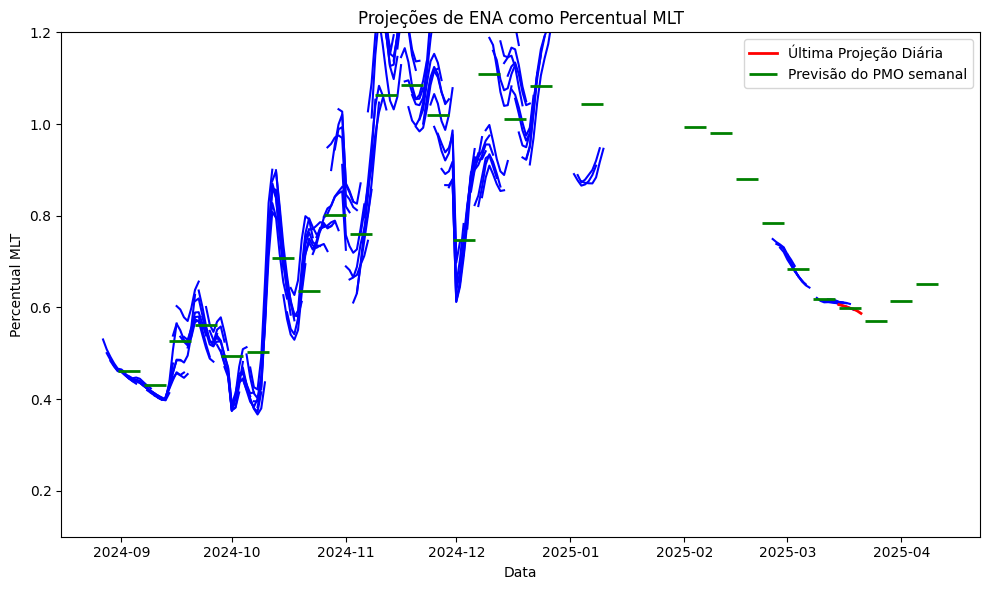

In [6]:
import matplotlib.pyplot as plt

# Garantir que as colunas 'data' e 'data_projecao' no grouped_data estão no formato de data
grouped_data['data'] = pd.to_datetime(grouped_data['data'])
grouped_data['data_projecao'] = pd.to_datetime(grouped_data['data_projecao'])

# Garantir que as colunas 'data_inicio' e 'data_fim' no grouped_data_pmo estão no formato de data
grouped_data_pmo['data_inicio'] = pd.to_datetime(grouped_data_pmo['data_inicio'])
grouped_data_pmo['data_fim'] = pd.to_datetime(grouped_data_pmo['data_fim'])

# Obter a última data_projecao
last_data_proj = grouped_data['data_projecao'].max()

# Criar o gráfico "hairy chart"
plt.figure(figsize=(10, 6))

# Definir as cores: uma cor para todas as linhas e outra cor para a última data_projecao
line_color = 'blue'
last_line_color = 'red'
pmo_color = 'green'  # Cor para os dados do PMO

# Plotar as linhas do grouped_data (projeções diárias) usando percentual_MLT
for data_proj in grouped_data['data_projecao'].unique():
    subset = grouped_data[grouped_data['data_projecao'] == data_proj]
    if data_proj == last_data_proj:
        plt.plot(subset['data'], subset['percentual_MLT'], color=last_line_color, linewidth=2, label='Última Projeção Diária')
    else:
        plt.plot(subset['data'], subset['percentual_MLT'], color=line_color)

# Plotar os dados do PMO como linhas retas de data_inicio a data_fim
for i, row in grouped_data_pmo.iterrows():
    plt.hlines(row['percentual_MLT'], row['data_inicio'], row['data_fim'], colors=pmo_color, linewidth=2, label="Previsão do PMO semanal" if i == 0 else "")

# Definir rótulos dos eixos e título
plt.xlabel('Data')
plt.ylabel('Percentual MLT')
plt.title('Projeções de ENA como Percentual MLT')

# Definir a escala do eixo Y entre 0.3 e 0.8
plt.ylim(0.1, 1.2)

# Adicionar a legenda
plt.legend()

# Exibir o gráfico
plt.tight_layout()
plt.show()


In [7]:
import requests

# Definir a URL base e a pasta de destino
base_url = "https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/ena_subsistema_di/ENA_DIARIO_SUBSISTEMA_{}.csv"
dest_folder = r'C:\Users\joao.barbosa\Codigos\Captura ENA\Data\Dados Brutos\arquivos_ENA'  # Pasta onde os arquivos serão salvos

# Pegar o ano atual
current_year = datetime.now().year

# Construir a URL para o ano atual
url = base_url.format(current_year)
file_path = os.path.join(dest_folder, f"ENA_DIARIO_SUBSISTEMA_{current_year}.csv")

# Certificar-se de que a pasta existe
if not os.path.exists(dest_folder):
    os.makedirs(dest_folder)

# Tentar baixar o arquivo do ano atual
try:
    print(f"Baixando: {url}")
    response = requests.get(url,verify=False)
    
    # Checar se o download foi bem-sucedido
    if response.status_code == 200:
        with open(file_path, 'wb') as file:
            file.write(response.content)
        print(f"Arquivo {file_path} salvo com sucesso!")
    else:
        print(f"Falha ao baixar o arquivo para o ano {current_year}. Status code: {response.status_code}")

except Exception as e:
    print(f"Erro ao baixar o arquivo para o ano {current_year}: {e}")

Baixando: https://ons-aws-prod-opendata.s3.amazonaws.com/dataset/ena_subsistema_di/ENA_DIARIO_SUBSISTEMA_2025.csv


c:\Users\joao.barbosa\AppData\Local\Programs\Python\Python312\Lib\site-packages\urllib3\connectionpool.py:1099: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ons-aws-prod-opendata.s3.amazonaws.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Arquivo C:\Users\joao.barbosa\Codigos\Captura ENA\Data\Dados Brutos\arquivos_ENA\ENA_DIARIO_SUBSISTEMA_2025.csv salvo com sucesso!


In [8]:
import pandas as pd

# Definir o caminho do arquivo CSV
file_path = r'C:\Users\joao.barbosa\Codigos\Captura ENA\Data\Dados Brutos\arquivos_ENA\ENA_DIARIO_SUBSISTEMA_2025.csv'

# Ler o arquivo CSV
ena_diario_subsistema_2024 = pd.read_csv(file_path,sep=';')


ena_diario_subsistema_2024['MLT'] = ena_diario_subsistema_2024['ena_bruta_regiao_mwmed']/ena_diario_subsistema_2024['ena_bruta_regiao_percentualmlt']*100
ena_diario_subsistema_2024['ena_data'] = pd.to_datetime(ena_diario_subsistema_2024['ena_data'])
grouped_ena_data = ena_diario_subsistema_2024.groupby('ena_data').sum().reset_index()
grouped_ena_data['percentual_MLT'] = grouped_ena_data['ena_bruta_regiao_mwmed']/grouped_ena_data['MLT']

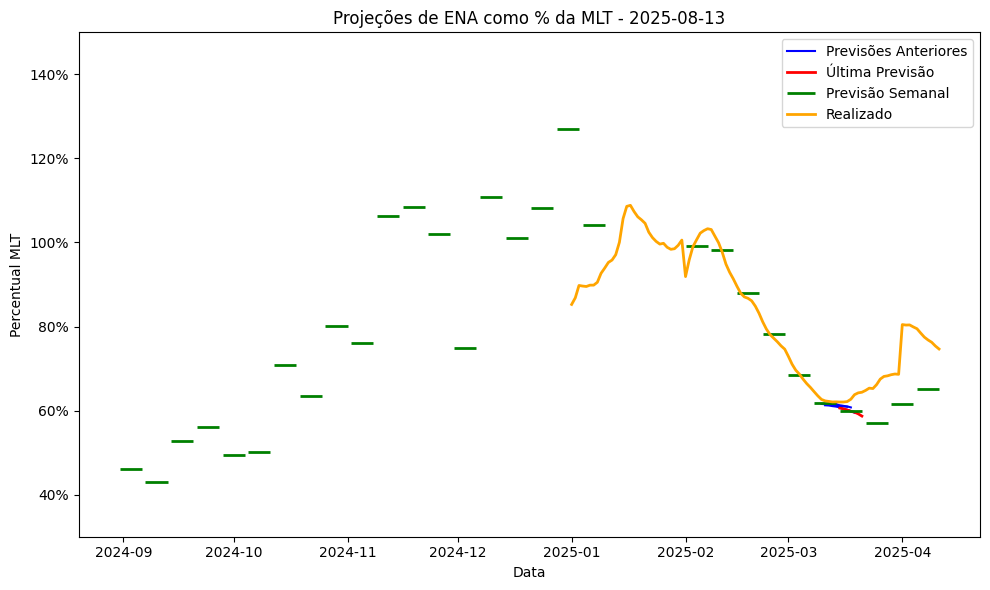

In [9]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd  # Certifique-se de importar pandas se ainda não estiver importado

# Supondo que grouped_ena_data, grouped_data, e grouped_data_pmo já estejam definidos

# Alterar o nome da coluna 'ena_data' para 'data' no grouped_ena_data
grouped_ena_data.rename(columns={'ena_data': 'data'}, inplace=True)

# Garantir que as colunas 'data' e 'data_projecao' no grouped_data estão no formato de data
grouped_data['data'] = pd.to_datetime(grouped_data['data'])
grouped_data['data_projecao'] = pd.to_datetime(grouped_data['data_projecao'])

# Garantir que as colunas 'data_inicio' e 'data_fim' no grouped_data_pmo estão no formato de data
grouped_data_pmo['data_inicio'] = pd.to_datetime(grouped_data_pmo['data_inicio'])
grouped_data_pmo['data_fim'] = pd.to_datetime(grouped_data_pmo['data_fim'])

# Garantir que a coluna 'data' no grouped_ena_data está no formato de data
grouped_ena_data['data'] = pd.to_datetime(grouped_ena_data['data'])

# Obter a última data_projecao
last_data_proj = grouped_data['data_projecao'].max()

# Definir o intervalo de tempo baseado nos dados existentes (mínima e máxima data)
min_data = min(grouped_data['data'].min(), grouped_data_pmo['data_inicio'].min())
max_data = max(grouped_data['data'].max(), grouped_data_pmo['data_fim'].max())

# Filtrar os dados de grouped_ena_data para corresponder ao intervalo de tempo
filtered_grouped_ena_data = grouped_ena_data[
    (grouped_ena_data['data'] >= min_data) & (grouped_ena_data['data'] <= max_data)
]

# Criar o gráfico "hairy chart"
plt.figure(figsize=(10, 6))

# Definir as cores: uma cor para todas as linhas e outra cor para a última data_projecao
line_color = 'blue'
last_line_color = 'red'
pmo_color = 'green'  # Cor para os dados do PMO
ena_data_color = 'orange'  # Cor para a nova base grouped_ena_data

# Variável para controlar a adição da legenda "Projeções anteriores"
label_added = False

# Plotar as linhas do grouped_data (projeções diárias) usando percentual_MLT
for data_proj in grouped_data['data_projecao'].tail(20).unique():
    subset = grouped_data[grouped_data['data_projecao'] == data_proj]
    if data_proj == last_data_proj:
        plt.plot(
            subset['data'],
            subset['percentual_MLT'],
            color=last_line_color,
            linewidth=2,
            label='Última Previsão'
        )
    else:
        if not label_added:
            plt.plot(
                subset['data'],
                subset['percentual_MLT'],
                color=line_color,
                label='Previsões Anteriores'  # Adiciona a legenda apenas uma vez
            )
            label_added = True
        else:
            plt.plot(
                subset['data'],
                subset['percentual_MLT'],
                color=line_color
            )

# Plotar os dados do PMO como linhas retas de data_inicio a data_fim
for i, row in grouped_data_pmo.iterrows():
    plt.hlines(
        row['percentual_MLT'],
        row['data_inicio'],
        row['data_fim'],
        colors=pmo_color,
        linewidth=2,
        label="Previsão Semanal" if i == 0 else ""
    )

# Plotar os dados da base filtered_grouped_ena_data (ENA Diário Subsistema) no intervalo de tempo filtrado
plt.plot(
    filtered_grouped_ena_data['data'],
    filtered_grouped_ena_data['percentual_MLT'],
    color=ena_data_color,
    linewidth=2,
    label='Realizado'
)

# Obtém a data de hoje
posicao = len(grouped_data) - 1
data = grouped_data['data_projecao'].iloc[posicao].date()

from datetime import date
hoje = date.today()


# Definir rótulos dos eixos e título
plt.xlabel('Data')
plt.ylabel('Percentual MLT')
plt.title(f'Projeções de ENA como % da MLT - {hoje}')

# Definir a escala do eixo Y entre 0.3 e 0.8
plt.ylim(0.3, 1.5)

# Formatar o eixo Y para exibir porcentagens
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

# Adicionar a legenda
plt.legend()

# Exibir o gráfico
plt.tight_layout()
plt.show()


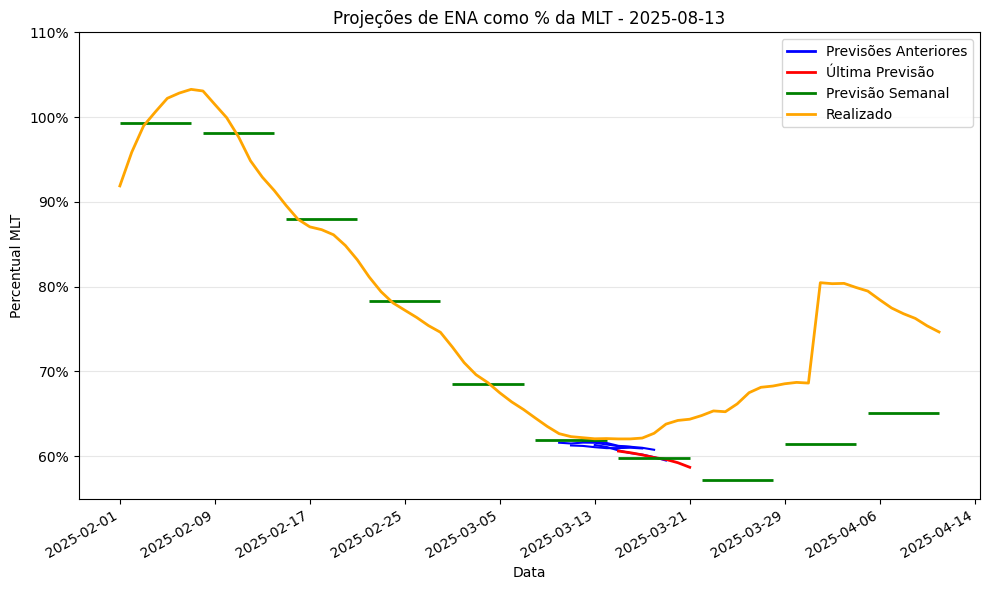

In [10]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd

# Supondo que grouped_ena_data, grouped_data, e grouped_data_pmo já estejam definidos

# ---- Definir o intervalo de datas ----
# Você pode definir as datas manualmente ou usar input para receber do usuário

# Método 1: Definir manualmente
data_inicial = '2025-02-01'  # Substitua pela data inicial desejada no formato 'YYYY-MM-DD'
data_final = '2025-04-11'    # Substitua pela data final desejada no formato 'YYYY-MM-DD'

# Método 2: Receber do usuário (descomente se preferir este método)
# data_inicial = input("Digite a data inicial (YYYY-MM-DD): ")
# data_final = input("Digite a data final (YYYY-MM-DD): ")

# Converter as strings para objetos datetime
data_inicial = pd.to_datetime(data_inicial)
data_final = pd.to_datetime(data_final)

# Verificar se data_inicial é anterior a data_final
if data_inicial > data_final:
    raise ValueError("A data inicial deve ser anterior ou igual à data final.")

# ---- Processamento dos dados ----

# Alterar o nome da coluna 'ena_data' para 'data' no grouped_ena_data
grouped_ena_data.rename(columns={'ena_data': 'data'}, inplace=True)

# Garantir que as colunas 'data' e 'data_projecao' no grouped_data estão no formato de data
grouped_data['data'] = pd.to_datetime(grouped_data['data'])
grouped_data['data_projecao'] = pd.to_datetime(grouped_data['data_projecao'])

# Garantir que as colunas 'data_inicio' e 'data_fim' no grouped_data_pmo estão no formato de data
grouped_data_pmo['data_inicio'] = pd.to_datetime(grouped_data_pmo['data_inicio'])
grouped_data_pmo['data_fim'] = pd.to_datetime(grouped_data_pmo['data_fim'])

# Garantir que a coluna 'data' no grouped_ena_data está no formato de data
grouped_ena_data['data'] = pd.to_datetime(grouped_ena_data['data'])

# Obter a última data_projecao
last_data_proj = grouped_data['data_projecao'].max()

# Definir o intervalo de tempo baseado nas datas fornecidas pelo usuário
min_data = data_inicial
max_data = data_final

# Filtrar os dados de grouped_data dentro do intervalo de tempo
filtered_grouped_data = grouped_data[
    (grouped_data['data'] >= min_data) & (grouped_data['data'] <= max_data)
]

# Filtrar os dados de grouped_data_pmo que têm qualquer sobreposição com o intervalo de tempo
filtered_grouped_data_pmo = grouped_data_pmo[
    (grouped_data_pmo['data_inicio'] <= max_data) & (grouped_data_pmo['data_fim'] >= min_data)
]

# Filtrar os dados de grouped_ena_data para corresponder ao intervalo de tempo
filtered_grouped_ena_data = grouped_ena_data[
    (grouped_ena_data['data'] >= min_data) & (grouped_ena_data['data'] <= max_data)
]

# ---- Criação do gráfico ----

plt.figure(figsize=(10, 6))

from matplotlib.lines import Line2D

# Definir as cores: uma cor para todas as linhas e outra cor para a última data_projecao
line_color = 'blue'
last_line_color = 'red'
pmo_color = 'green'  # Cor para os dados do PMO
ena_data_color = 'orange'  # Cor para a nova base grouped_ena_data

# Variável para controlar a adição da legenda "Previsões Anteriores"
label_added = False

# Plotar as linhas do filtered_grouped_data (projeções diárias) usando percentual_MLT
for data_proj in filtered_grouped_data['data_projecao'].tail(20).unique():
    subset = filtered_grouped_data[filtered_grouped_data['data_projecao'] == data_proj]
    if data_proj == last_data_proj:
        plt.plot(
            subset['data'],
            subset['percentual_MLT'],
            color=last_line_color,
            linewidth=2,
            label='Última Previsão'
        )
    else:
        if not label_added:
            plt.plot(
                subset['data'],
                subset['percentual_MLT'],
                color=line_color,
                label='Previsões Anteriores'  # Adiciona a legenda apenas uma vez
            )
            label_added = True
        else:
            plt.plot(
                subset['data'],
                subset['percentual_MLT'],
                color=line_color
            )

# Plotar os dados do PMO como linhas retas de data_inicio a data_fim
for i, row in filtered_grouped_data_pmo.iterrows():
    plt.hlines(
        row['percentual_MLT'],
        max(row['data_inicio'], min_data),  # Iniciar no máximo entre data_inicio e min_data
        min(row['data_fim'], max_data),    # Terminar no mínimo entre data_fim e max_data
        colors=pmo_color,
        linewidth=2,
        label="Previsão Semanal" if i == 0 else None
    )

# Plotar os dados da base filtered_grouped_ena_data (ENA Diário Subsistema) no intervalo de tempo filtrado
plt.plot(
    filtered_grouped_ena_data['data'],
    filtered_grouped_ena_data['percentual_MLT'],
    color=ena_data_color,
    linewidth=2,
    label='Realizado'
)

# Definir rótulos dos eixos e título
plt.xlabel('Data')
plt.ylabel('Percentual MLT')
plt.title(f'Projeções de ENA como % da MLT - {hoje}')

# Definir a escala do eixo Y entre 0.3 e 0.8
plt.ylim(0.55, 1.1)

# Formatar o eixo Y para exibir porcentagens
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))

# Formatar o eixo X para melhorar a visualização das datas
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(10))  # Limita o número de ticks no eixo X
plt.gcf().autofmt_xdate()  # Rotaciona os rótulos do eixo X para melhor legibilidade

# Criação de Handles Personalizados para a Legenda
legend_elements = [
    Line2D([0], [0], color=line_color, lw=2, label='Previsões Anteriores'),
    Line2D([0], [0], color=last_line_color, lw=2, label='Última Previsão'),
    Line2D([0], [0], color=pmo_color, lw=2, label='Previsão Semanal'),
    Line2D([0], [0], color=ena_data_color, lw=2, label='Realizado')
]


# Adicionar a legenda com os handles personalizados
plt.legend(handles=legend_elements)

# Adicionar gridlines no eixo Y
plt.grid(axis='y', linestyle='-', alpha=0.3)

# Exibir o gráfico
plt.tight_layout()
plt.show()


In [20]:
### Consultar Relatório de Previsão de Vazões e Geração de Cenários de Afluências do PMO mensal, ultima atualização Revisao da 2ª semana
### Consultuar Resultados Preliminares Consistidos (vazões semanais - PMO), acho que sai na quinta a noite antes da publicação do PMO